In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/mdm2_data_files/master_mobility_model_data.csv"
df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

print(df.shape)
print(df.columns.tolist())

/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


(379477, 27)
['sensor_id', 'datetime', 'date_only', 'hour', 'dow', 'is_weekend', 'week', 'month', 'year', 'longitude', 'latitude', 'cluster_geo', 'ward_name', 'ped', 'cyc', 'car', 'active', 'solar_altitude_deg', 'light_class', 'Dark', 'temp_c', 'wind_ms', 'rain_mm', 'cctv_300m', 'safety_after_dark_pct', 'safety_scaled', 'weekday']


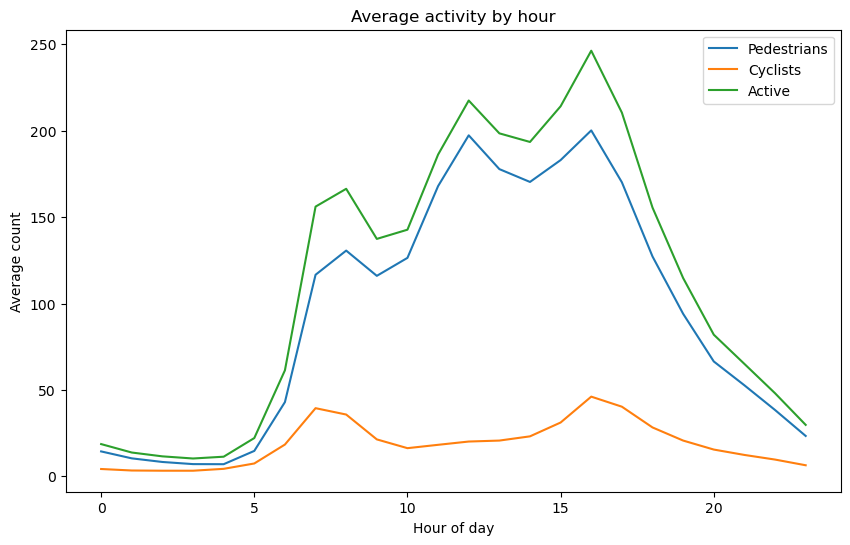

In [3]:
hourly = df.groupby("hour")[["ped", "cyc", "active"]].mean().reset_index()

plt.figure(figsize=(10,6))
plt.plot(hourly["hour"].to_numpy(), hourly["ped"].to_numpy(), label="Pedestrians")
plt.plot(hourly["hour"].to_numpy(), hourly["cyc"].to_numpy(), label="Cyclists")
plt.plot(hourly["hour"].to_numpy(), hourly["active"].to_numpy(), label="Active")
plt.xlabel("Hour of day")
plt.ylabel("Average count")
plt.title("Average activity by hour")
plt.legend()
plt.show()

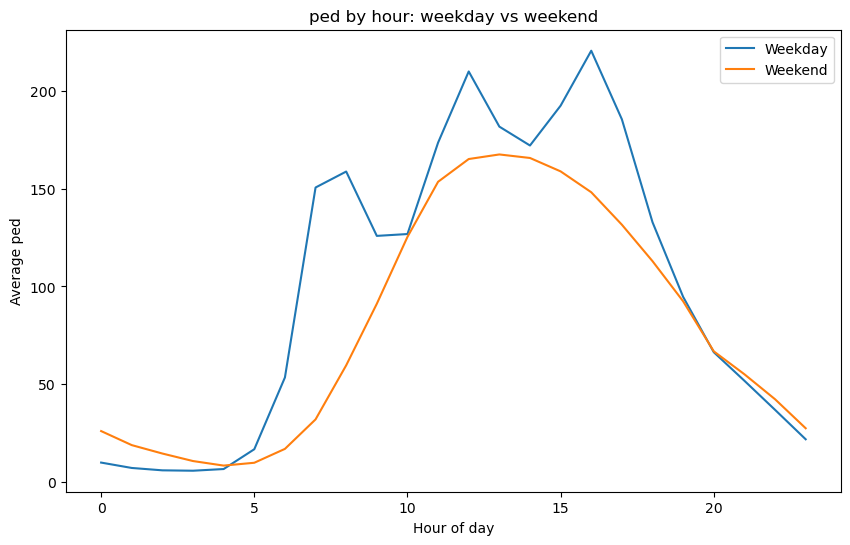

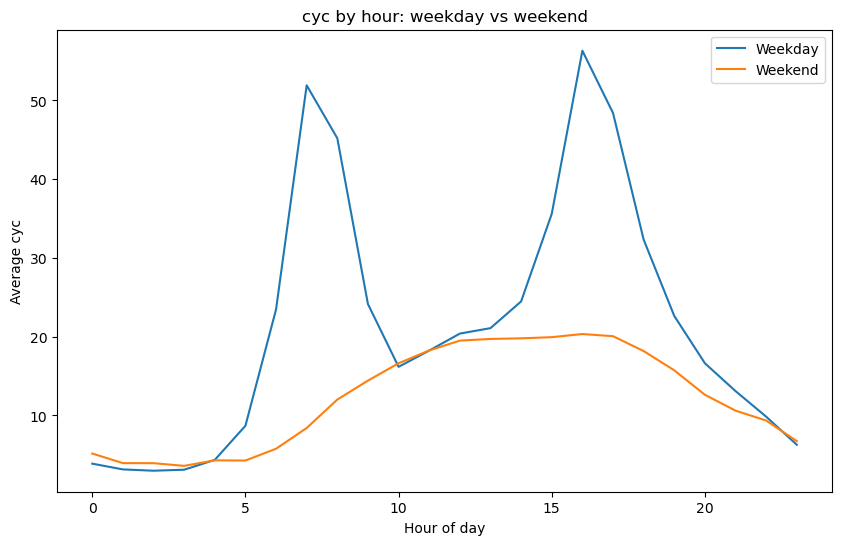

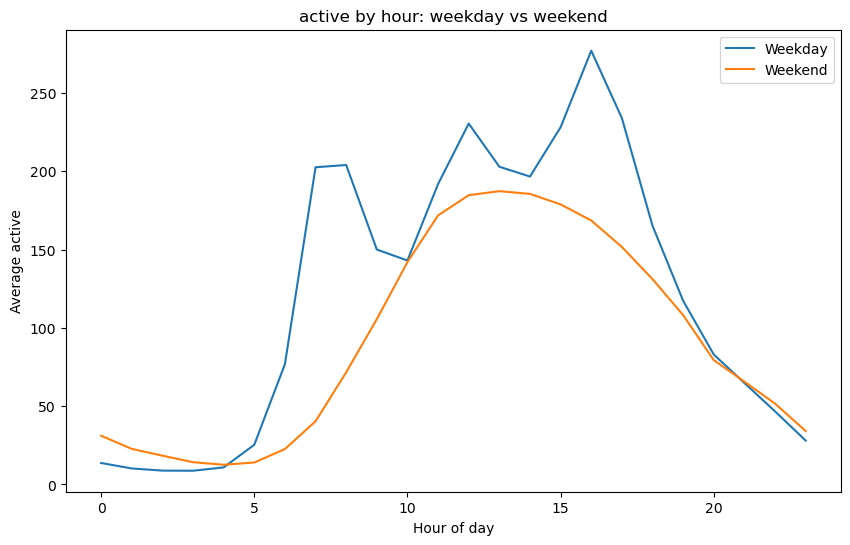

In [4]:
hourly_we = df.groupby(["hour", "is_weekend"])[["ped", "cyc", "active"]].mean().reset_index()

for var in ["ped", "cyc", "active"]:
    plt.figure(figsize=(10,6))
    for w, label in [(0, "Weekday"), (1, "Weekend")]:
        sub = hourly_we[hourly_we["is_weekend"] == w]
        plt.plot(sub["hour"].to_numpy(), sub[var].to_numpy(), label=label)
    plt.xlabel("Hour of day")
    plt.ylabel(f"Average {var}")
    plt.title(f"{var} by hour: weekday vs weekend")
    plt.legend()
    plt.show()

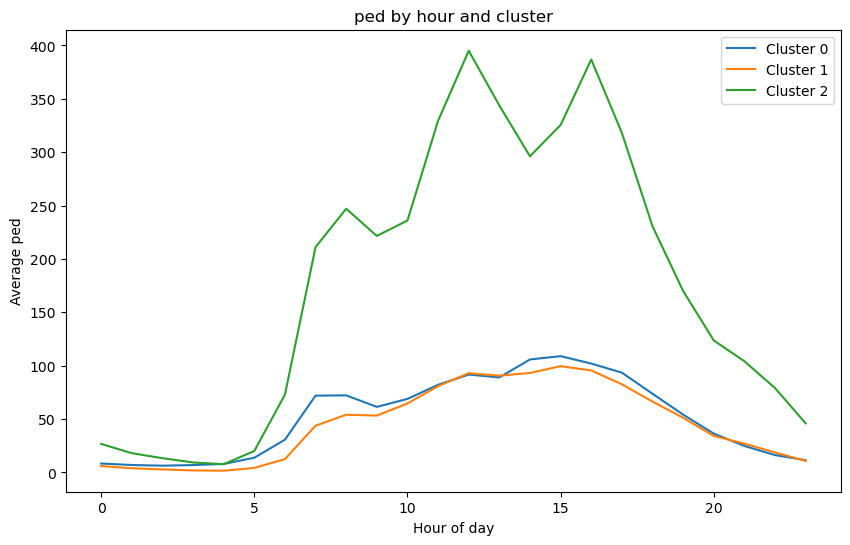

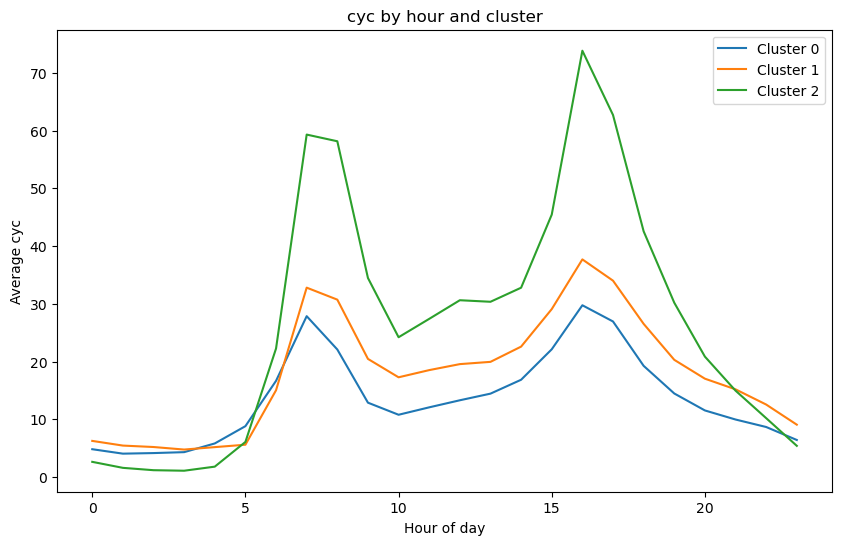

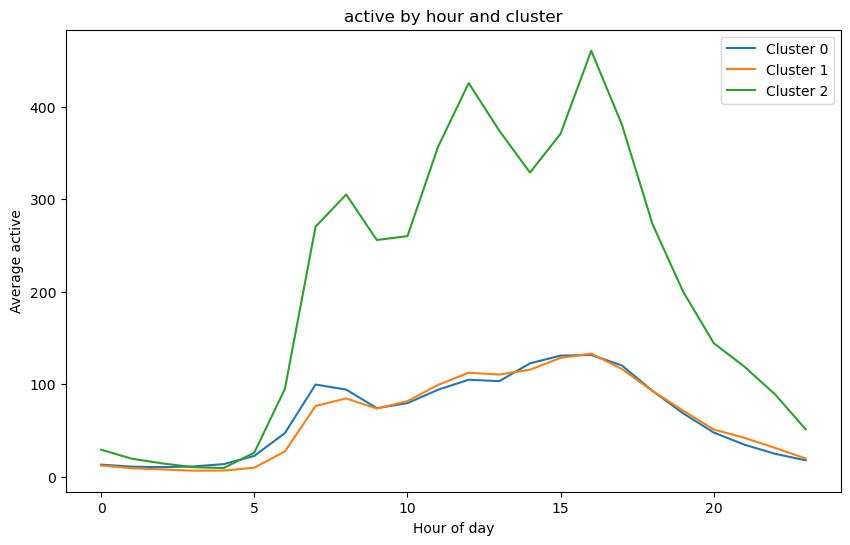

In [5]:
hourly_cluster = df.groupby(["hour", "cluster_geo"])[["ped", "cyc", "active"]].mean().reset_index()

for var in ["ped", "cyc", "active"]:
    plt.figure(figsize=(10,6))
    for c in sorted(df["cluster_geo"].unique()):
        sub = hourly_cluster[hourly_cluster["cluster_geo"] == c]
        plt.plot(sub["hour"].to_numpy(), sub[var].to_numpy(), label=f"Cluster {c}")
    plt.xlabel("Hour of day")
    plt.ylabel(f"Average {var}")
    plt.title(f"{var} by hour and cluster")
    plt.legend()
    plt.show()

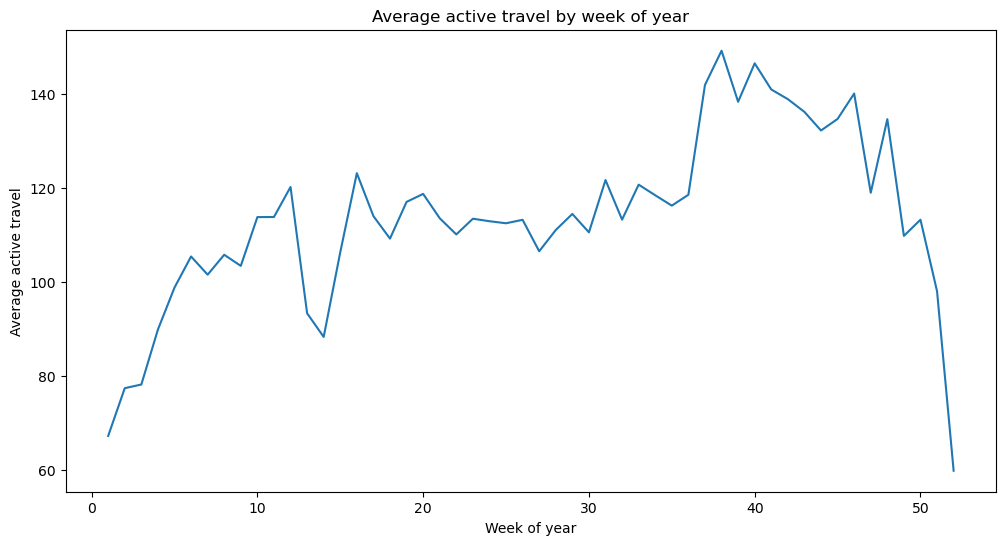

In [6]:
weekly = df.groupby("week")[["ped", "cyc", "active"]].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(weekly["week"].to_numpy(), weekly["active"].to_numpy())
plt.xlabel("Week of year")
plt.ylabel("Average active travel")
plt.title("Average active travel by week of year")
plt.show()

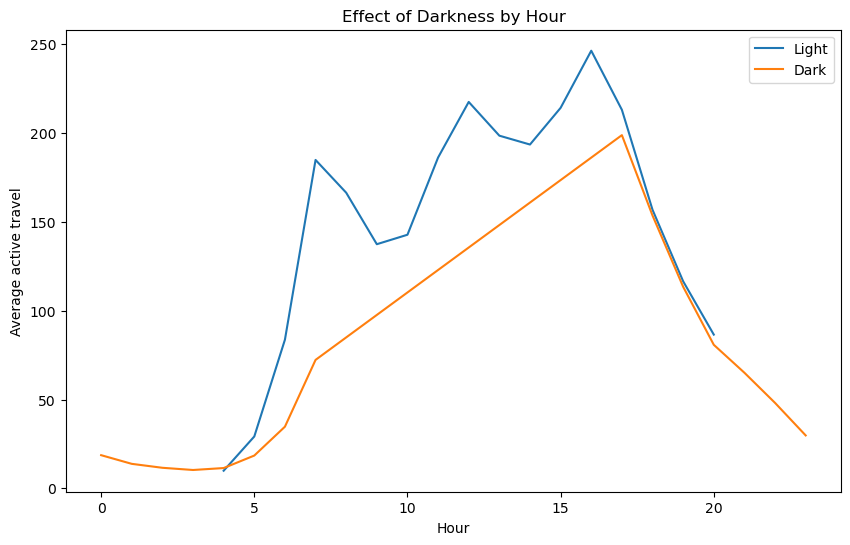

In [8]:
dark_hour = df.groupby(["hour","Dark"])["active"].mean().reset_index()

plt.figure(figsize=(10,6))

for d, label in [(0, "Light"), (1, "Dark")]:
    sub = dark_hour[dark_hour["Dark"] == d]
    plt.plot(sub["hour"].to_numpy(), sub["active"].to_numpy(), label=label)

plt.xlabel("Hour")
plt.ylabel("Average active travel")
plt.title("Effect of Darkness by Hour")
plt.legend()
plt.show()

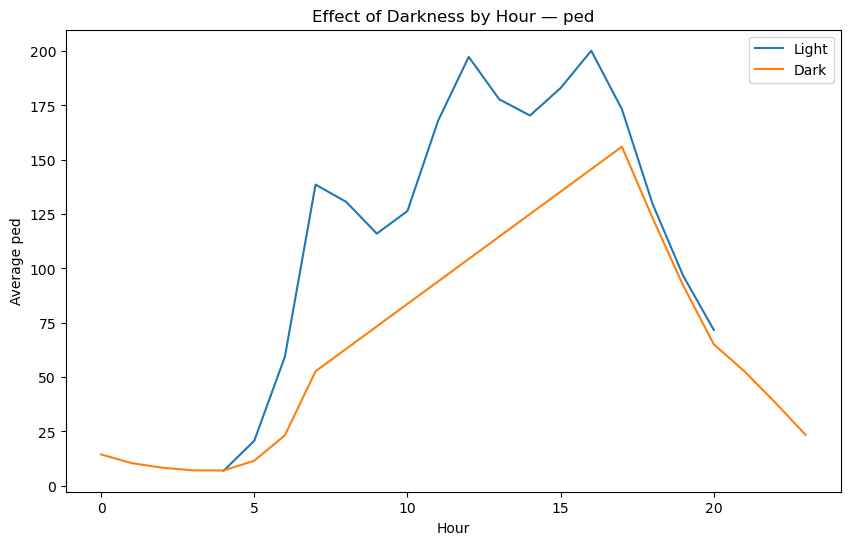

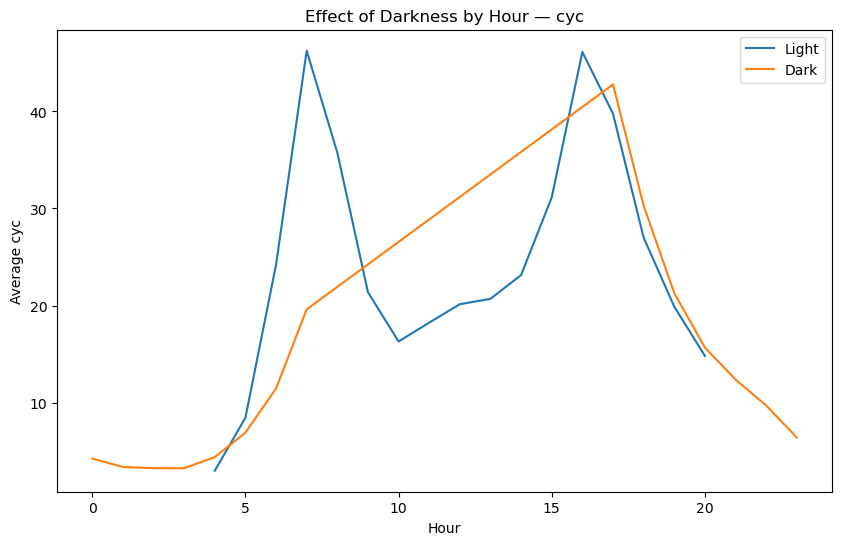

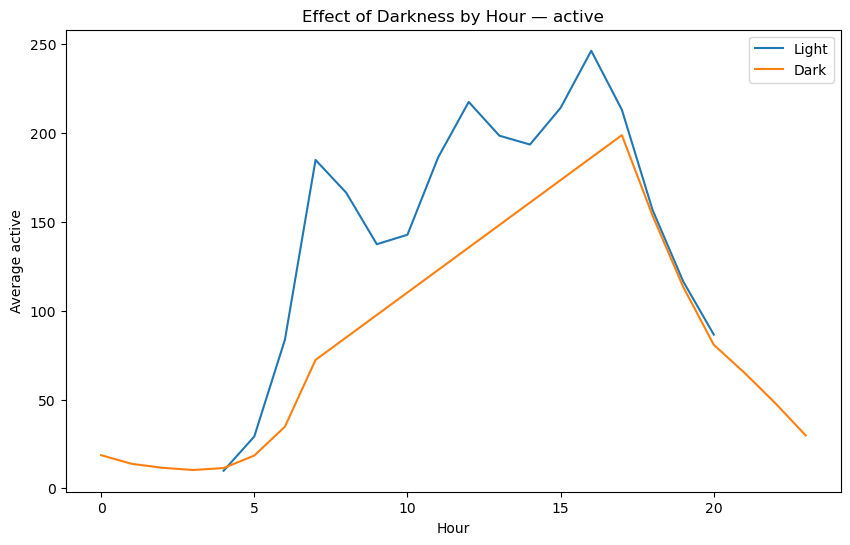

In [9]:
for var in ["ped", "cyc", "active"]:
    dark_hour = df.groupby(["hour","Dark"])[var].mean().reset_index()

    plt.figure(figsize=(10,6))
    for d, label in [(0, "Light"), (1, "Dark")]:
        sub = dark_hour[dark_hour["Dark"] == d]
        plt.plot(sub["hour"].to_numpy(), sub[var].to_numpy(), label=label)

    plt.xlabel("Hour")
    plt.ylabel(f"Average {var}")
    plt.title(f"Effect of Darkness by Hour — {var}")
    plt.legend()
    plt.show()

Average active travel levels during dark hours are consistently lower than during daylight hours across all times of day. During peak commuting periods, pedestrian counts can be up to 40% lower in darkness compared to daylight. This suggests that perceived safety and visibility during dark hours may play a significant role in travel behaviour.


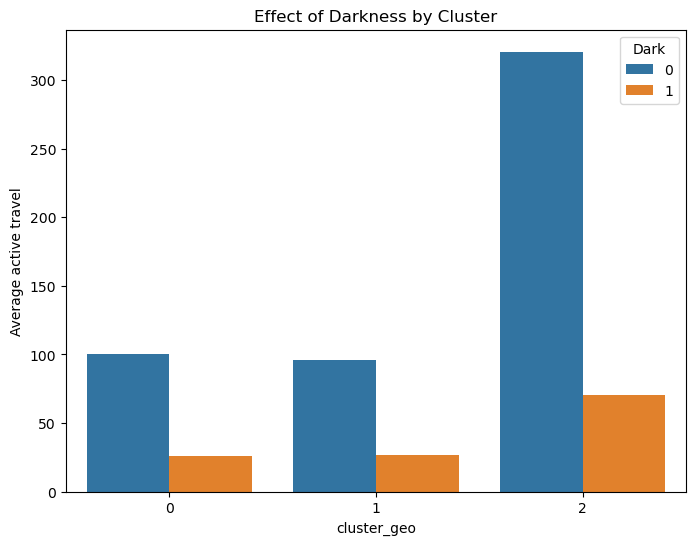

In [10]:
cluster_dark = df.groupby(["cluster_geo","Dark"])["active"].mean().reset_index()

import seaborn as sns
plt.figure(figsize=(8,6))
sns.barplot(data=cluster_dark, x="cluster_geo", y="active", hue="Dark")
plt.title("Effect of Darkness by Cluster")
plt.ylabel("Average active travel")
plt.show()

Active travel levels are substantially higher during daylight across all urban clusters. In the city centre cluster, average active travel drops from approximately 320 travellers per hour in daylight to around 70 in darkness. Similar proportional declines are observed in residential clusters, indicating that darkness is associated with lower levels of walking and cycling activity across the city.